<a href="https://colab.research.google.com/github/aleja71291/FDL-EA-20252/blob/main/2_Transformacion_2D_ADNI1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transformación de datos tabulares en imágenes 2D

Las redes convolucionales tienen la capacidad de explotar las relaciones espaciales inherentes de los datos obtenidos, por lo que se ajustan a la mayoría de tareas de análisis de imágenes. Su aplicación en datos tabulares es, por lo tanto, limitada. Por lo anterior, probaremos transformar los datos tabulares preprocesados anteriormente, en imágenes sintéticas.
Para esta tarea nos basaremos en el proceso descrito por Zhu et al.
Referencia: Zhu, Y., Brettin, T., Xia, F. et al. Converting tabular data into images for deep learning with convolutional neural networks. Sci Rep 11, 11325 (2021). https://doi.org/10.1038/s41598-021-90923-y

https://github.com/zhuyitan/IGTD

# ¿Por qué tiene sentido transformar los datos de esta manera?

En la enfermedad de Alzheimer, se espera que los cambios en el volumen de las diferentes estructuras cerebrales afectadas, tengan relación espacial entre sí, dado las conexiones intra e inter-lobares, así como las conexiones existentes entre la corteza cerebral y estructuras subcorticales, a través de las redes axonales subcorticales (ver figura).
Es importante recordar que los datos tabulares de esta base de datos tienen las mismas unidades (milímetros cúbicos) y fueron obtenidos de cada participante en la misma forma (análisis de imágenes estructurales de resonancia magnética a través de Freesurfer).

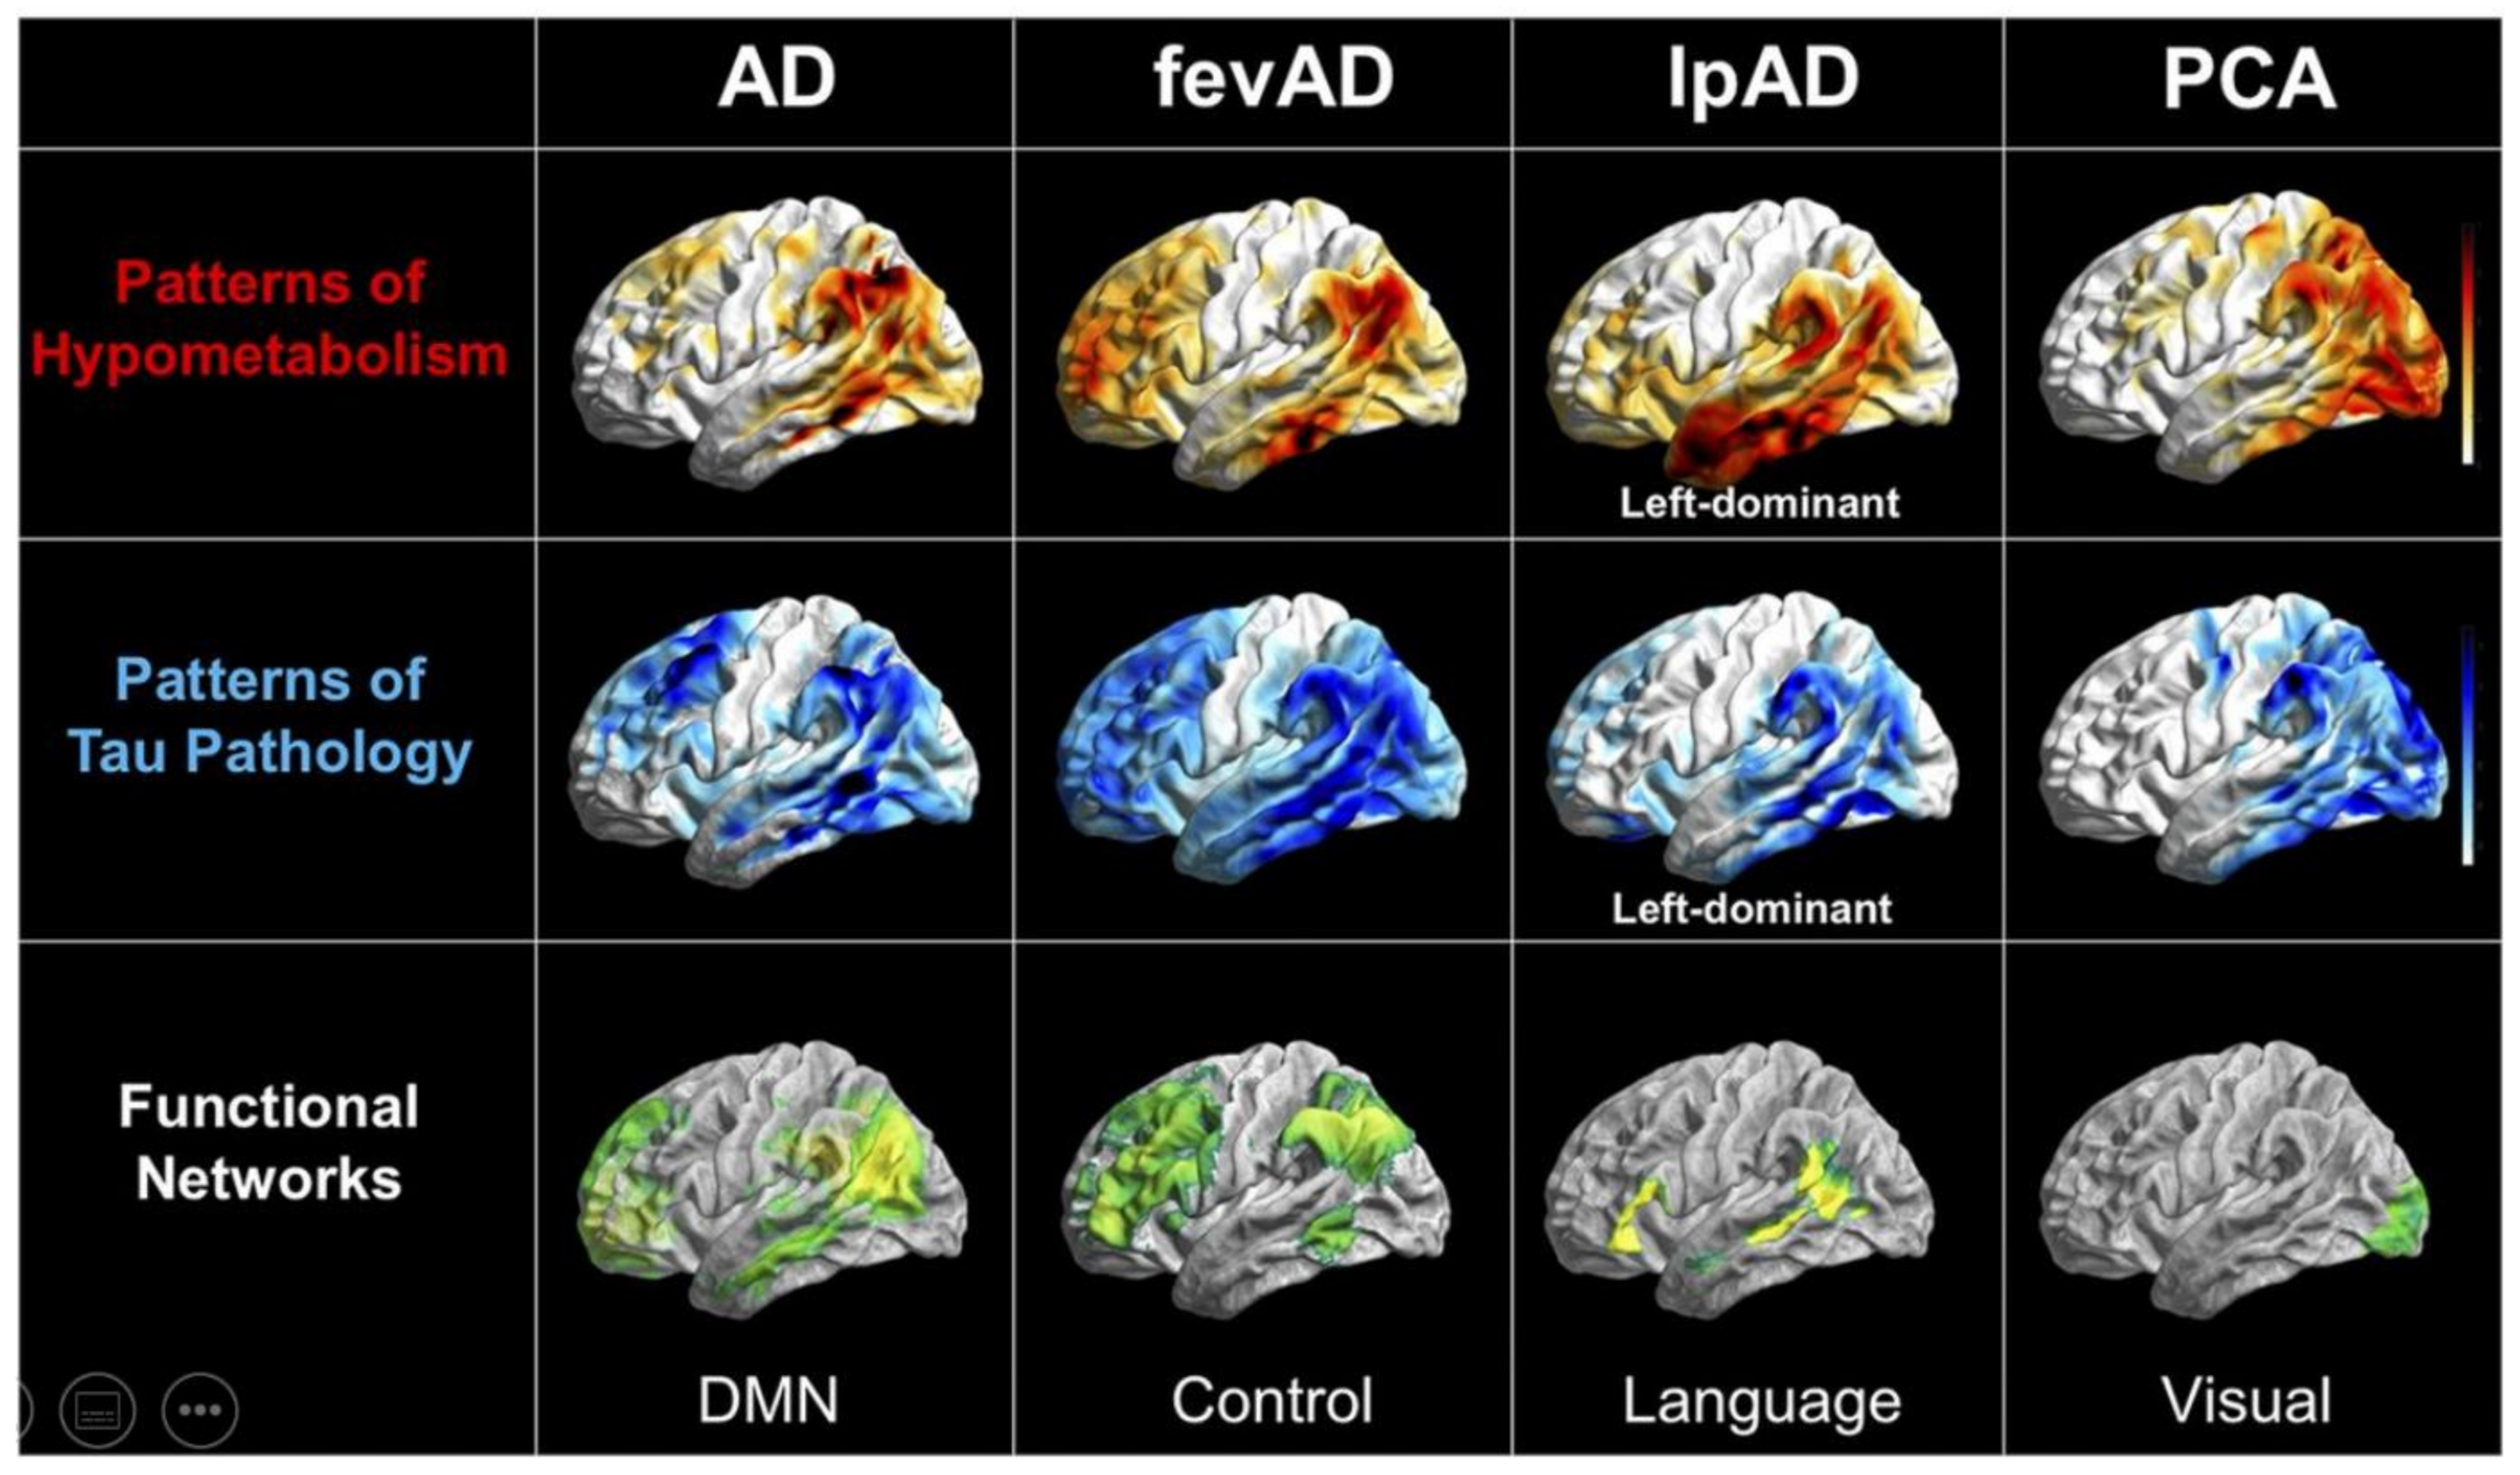

In [ ]:
from PIL import Image
import requests
from io import BytesIO
from IPython.display import display
url = 'https://raw.githubusercontent.com/aleja71291/FDL-EA-20252/refs/heads/main/content/EA_atrofia_redes.png'
response = requests.get(url)
img = Image.open(BytesIO(response.content))
display(img)

# Preparación de los datos
Importamos los datos de volumen (X) del set de entrenamiento remuestreado. Removemos las columnas que no corresponden a valores de volumen de estructuras cerebrales.

In [ ]:
import pandas as pd
csv_url = "https://raw.githubusercontent.com/aleja71291/FDL-EA-20252/refs/heads/main/content/X_resampled_df%20(1).csv"
X_resampledfull_df = pd.read_csv(csv_url)
print(X_resampledfull_df.head())

    RID_x  CDSOURCE  CDMEMORY  CDORIENT  CDJUDGE  CDCOMMUN  CDHOME  CDCARE  \
0   217.0       1.0       1.0       1.0      0.5       0.5     1.0     0.0   
1   883.0       1.0       0.0       0.0      0.0       0.0     0.0     0.0   
2  1249.0       1.0       0.0       0.0      0.0       0.0     0.0     0.0   
3   575.0       2.0       0.0       0.0      0.0       0.0     0.0     0.0   
4   844.0       1.0       1.0       1.0      2.0       2.0     1.0     0.0   

   CDRSB      ID  ...   ST9SV        ST147SV        ST148SV        ST149SV  \
0    4.0  5454.0  ...  1655.6  179002.193943  179331.930907  358334.124850   
1    0.0  7040.0  ...  2850.9  184710.081101  194206.906399  378916.987500   
2    0.0  7068.0  ...  1709.8  184078.106672  186605.943462  370684.050133   
3    0.0  6584.0  ...  1553.3  160552.338347  171213.262766  331765.601113   
4    7.0  6776.0  ...  2238.8  165039.381302  166374.116787  331413.498089   

    ST150SV   ST151SV   ST152SV  ST153SV        ST154SV   ST15

In [ ]:
columns_to_drop = [
    'RID_y', 'CDSOURCE', 'CDMEMORY', 'CDORIENT', 'CDJUDGE',
    'CDCOMMUN', 'CDHOME', 'CDCARE', 'CDRSB',
    'ID', 'SITEID', 'IMAGEUID'
]

X_resampled_df = X_resampledfull_df.drop(columns=columns_to_drop, errors='ignore')
print(X_resampled_df.head())

    RID_x  ST101SV  ST102CV  ST102SA  ST102TA  ST102TS  ST103CV  ST103SA  \
0   217.0   1360.2   3345.0   1448.0    2.196    582.0   1776.0    593.0   
1   883.0   1613.1   2583.0   1240.0    2.022    575.0   1960.0    639.0   
2  1249.0   1720.8   3156.0   1272.0    2.286    576.0   1597.0    576.0   
3   575.0   1597.4   2721.0   1238.0    2.130    599.0   1326.0    594.0   
4   844.0   1335.8   2096.0   1435.0    1.535    392.0   1473.0    677.0   

   ST103TA  ST103TS  ...   ST9SV        ST147SV        ST148SV        ST149SV  \
0    2.475    763.0  ...  1655.6  179002.193943  179331.930907  358334.124850   
1    2.600    825.0  ...  2850.9  184710.081101  194206.906399  378916.987500   
2    2.381    715.0  ...  1709.8  184078.106672  186605.943462  370684.050133   
3    1.936    698.0  ...  1553.3  160552.338347  171213.262766  331765.601113   
4    1.876    614.0  ...  2238.8  165039.381302  166374.116787  331413.498089   

    ST150SV   ST151SV   ST152SV  ST153SV        ST154SV 

# Transformación de los datos
Descargamos e implementamos las funciones desarrolladas por Zhu et al. En estas funciones, existen dos formas para calcular la distancia entre pixeles (Euclidiana o Pearson) y dos formas para calcular la diferencia entre la distancia entre características y distancia entre píxeles (Euclidiana o Manhattan).

No esperamos una correlación lineal, sin embargo, en el contexto de este ejercicio, probaremos los resultados utilizando ambos métodos.

In [ ]:
!wget https://raw.githubusercontent.com/aleja71291/FDL-EA-20252/refs/heads/main/content/IGTD_Functions.py -O IGTD_Functions.py

--2025-11-09 21:53:29--  https://raw.githubusercontent.com/aleja71291/FDL-EA-20252/refs/heads/main/content/IGTD_Functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 33142 (32K) [text/plain]
Saving to: ‘IGTD_Functions.py’

IGTD_Functions.py   100%[===================>]  32.37K  --.-KB/s    in 0.003s  

2025-11-09 21:53:29 (12.5 MB/s) - ‘IGTD_Functions.py’ saved [33142/33142]



In [ ]:
import os
from IGTD_Functions import min_max_transform, table_to_image, select_features_by_variation



num_row = 13    # Number of pixel rows in image representation
num_col = 25    # Number of pixel columns in image representation
num = num_row * num_col # Number of features to be included for analysis, which is also the total number of pixels in image representation
save_image_size = 3 # Size of pictures (in inches) saved during the execution of IGTD algorithm.
max_step = 30000    # The maximum number of iterations to run the IGTD algorithm, if it does not converge.
val_step = 300  # The number of iterations for determining algorithm convergence. If the error reduction rate
                # is smaller than a pre-set threshold for val_step itertions, the algorithm converges.

# Import the example data and linearly scale each feature so that its minimum and maximum values are 0 and 1, respectively.
data = X_resampled_df.copy()

# Select features with large variations across samples
id = select_features_by_variation(data, variation_measure='var', num=num)
data = data.iloc[:, id]

# Perform min-max transformation so that the maximum and minimum values of every feature become 1 and 0, respectively.
norm_data = min_max_transform(data.values)
norm_data = pd.DataFrame(norm_data, columns=data.columns, index=data.index)

# Run the IGTD algorithm using (1) the Euclidean distance for calculating pairwise feature distances and pariwise pixel
# distances and (2) the absolute function for evaluating the difference between the feature distance ranking matrix and
# the pixel distance ranking matrix. Save the result in Test_1 folder.
fea_dist_method = 'Euclidean'
image_dist_method = 'Euclidean'
error = 'abs'
result_dir = '../Results/Table_To_Image_Conversion/Test_1'
os.makedirs(name=result_dir, exist_ok=True)
table_to_image(norm_data, [num_row, num_col], fea_dist_method, image_dist_method, save_image_size,
               max_step, val_step, result_dir, error)

# Run the IGTD algorithm using (1) the Pearson correlation coefficient for calculating pairwise feature distances,
# (2) the Manhattan distance for calculating pariwise pixel distances, and (3) the square function for evaluating
# the difference between the feature distance ranking matrix and the pixel distance ranking matrix.
# Save the result in Test_2 folder.
fea_dist_method = 'Pearson'
image_dist_method = 'Manhattan'
error = 'squared'
norm_data = norm_data.iloc[:, :800]
result_dir = '../Results/Table_To_Image_Conversion/Test_2'
os.makedirs(name=result_dir, exist_ok=True)
table_to_image(norm_data, [num_row, num_col], fea_dist_method, image_dist_method, save_image_size,
               max_step, val_step, result_dir, error)

Step 0 err: 922691215.0
Step 1 err: 919156620.0
Step 2 err: 914453385.0
Step 3 err: 912900653.0
Step 4 err: 911092772.0
Step 5 err: 907500021.0
Step 6 err: 906439387.0
Step 7 err: 902068125.0
Step 8 err: 896309593.0
Step 9 err: 894043486.0
Step 10 err: 890706509.0
Step 11 err: 887933780.0
Step 12 err: 887062497.0
Step 13 err: 885293932.0
Step 14 err: 880566235.0
Step 15 err: 876205003.0
Step 16 err: 874396533.0
Step 17 err: 872828120.0
Step 18 err: 867620526.0
Step 19 err: 866995566.0
Step 20 err: 862947740.0
Step 21 err: 862145440.0
Step 22 err: 859824341.0
Step 23 err: 859183027.0
Step 24 err: 858757849.0
Step 25 err: 854730003.0
Step 26 err: 853584488.0
Step 27 err: 852569578.0
Step 28 err: 849532766.0
Step 29 err: 848495347.0
Step 30 err: 847720672.0
Step 31 err: 845987172.0
Step 32 err: 845066869.0
Step 33 err: 842417590.0
Step 34 err: 841057905.0
Step 35 err: 838979779.0
Step 36 err: 838467785.0
Step 37 err: 835918821.0
Step 38 err: 834071666.0
Step 39 err: 833022931.0
Step 40 er

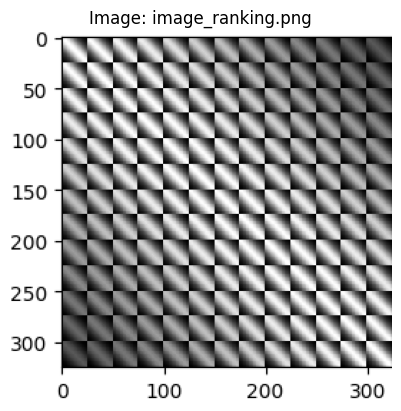

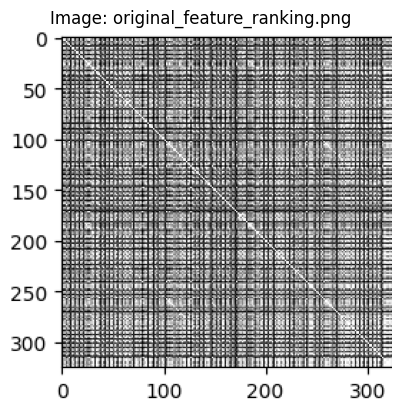

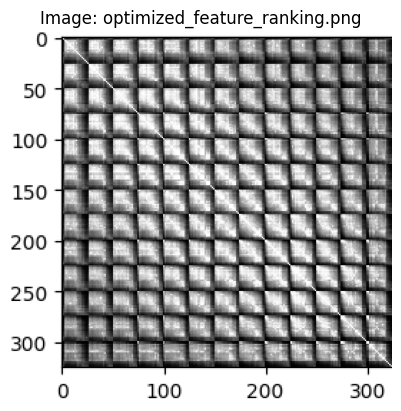

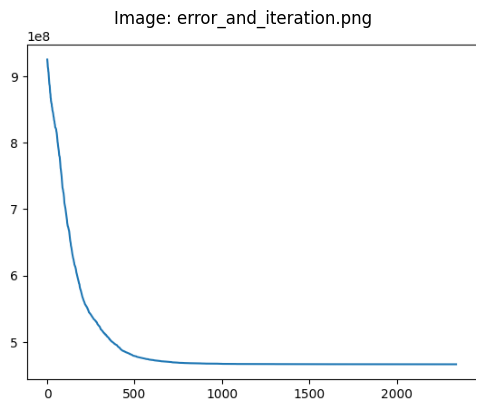

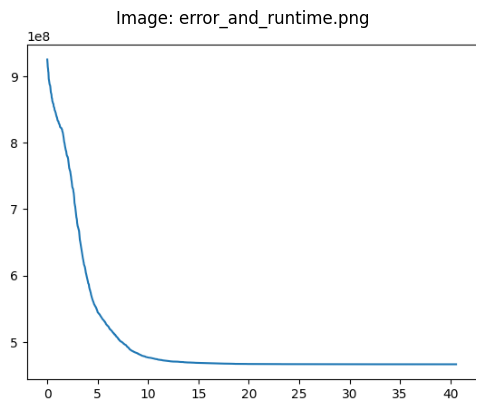

In [ ]:
import matplotlib.pyplot as plt
import os
from PIL import Image

image_dir = '../Results/Table_To_Image_Conversion/Test_1'
images = [f for f in os.listdir(image_dir) if f.endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

for img_file in images:
    img_path = os.path.join(image_dir, img_file)
    img = Image.open(img_path)
    plt.figure()
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Image: {img_file}")
    plt.show()

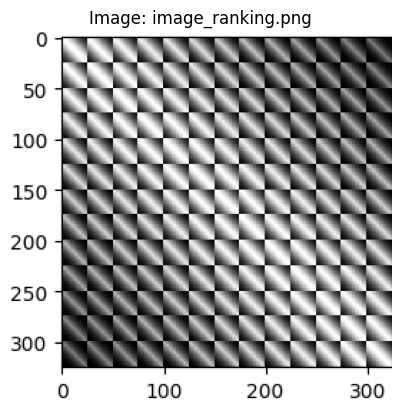

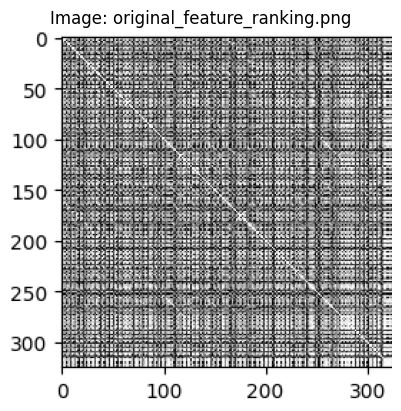

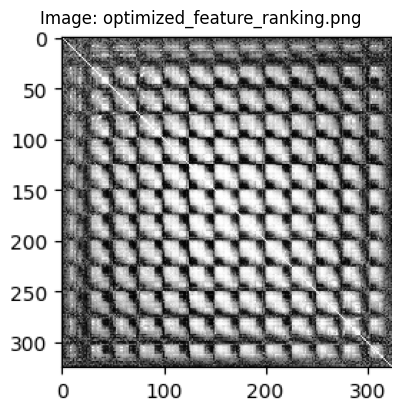

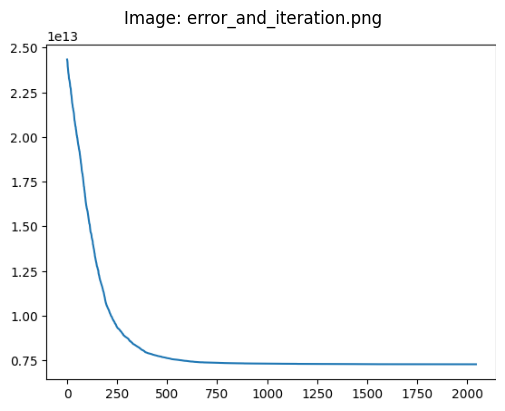

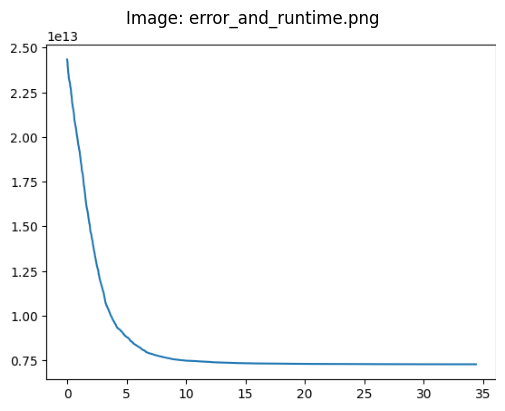

In [ ]:
image_dir = '../Results/Table_To_Image_Conversion/Test_2'
images = [f for f in os.listdir(image_dir) if f.endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

for img_file in images:
    img_path = os.path.join(image_dir, img_file)
    img = Image.open(img_path)
    plt.figure()
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Image: {img_file}")
    plt.show()

Se repite el proceso con el set de prueba (no re-muestreado).

In [ ]:
import pandas as pd

csv_url2 = "https://raw.githubusercontent.com/aleja71291/FDL-EA-20252/refs/heads/main/content/X_test%20(1).csv"
X_test_df = pd.read_csv(csv_url2)
X_test_df.columns = X_resampledfull_df.columns

columns_to_drop = [
    'RID_y', 'CDSOURCE', 'CDMEMORY', 'CDORIENT', 'CDJUDGE',
    'CDCOMMUN', 'CDHOME', 'CDCARE', 'CDRSB',
    'ID', 'SITEID', 'IMAGEUID'
]

X_test_df = X_test_df.drop(columns=columns_to_drop, errors='ignore')
print(X_test_df.head())

    RID_x  ST101SV  ST102CV  ST102SA  ST102TA  ST102TS  ST103CV  ST103SA  \
0   675.0   1438.2   3453.0   1529.0    2.132    705.0   1428.0    592.0   
1  1351.0   1659.2   3230.0   1456.0    2.099      0.6   1329.0    446.0   
2  1109.0   1729.3   2981.0   1508.0    1.941    571.0   1390.0    494.0   
3   916.0   1277.1   3417.0   1282.0    2.415    696.0   1371.0    548.0   
4   378.0   1579.0   3220.0   1333.0    2.274    602.0   1590.0    508.0   

   ST103TA  ST103TS  ...   ST9SV        ST147SV        ST148SV        ST149SV  \
0    2.041    787.0  ...  1271.4  166141.612424  159172.811940  325314.424363   
1    2.455    852.0  ...  1502.6  185725.750462  196958.288593  382684.039055   
2    2.347    798.0  ...  1461.2  147708.345583  150998.610540  298706.956123   
3    2.170    746.0  ...  2189.7  176646.170396  189415.427631  366061.598027   
4    2.645    993.0  ...  2214.2  188788.929611  185973.052401  374761.982012   

    ST150SV   ST151SV   ST152SV  ST153SV        ST154SV 

In [ ]:
import os
from IGTD_Functions import min_max_transform, table_to_image, select_features_by_variation



num_row = 13    # Number of pixel rows in image representation
num_col = 25    # Number of pixel columns in image representation
num = num_row * num_col # Number of features to be included for analysis, which is also the total number of pixels in image representation
save_image_size = 3 # Size of pictures (in inches) saved during the execution of IGTD algorithm.
max_step = 30000    # The maximum number of iterations to run the IGTD algorithm, if it does not converge.
val_step = 300  # The number of iterations for determining algorithm convergence. If the error reduction rate
                # is smaller than a pre-set threshold for val_step itertions, the algorithm converges.

# Import the example data and linearly scale each feature so that its minimum and maximum values are 0 and 1, respectively.
data = X_test_df.copy()

# Select features with large variations across samples
id = select_features_by_variation(data, variation_measure='var', num=num)
data = data.iloc[:, id]

# Perform min-max transformation so that the maximum and minimum values of every feature become 1 and 0, respectively.
norm_data = min_max_transform(data.values)
norm_data = pd.DataFrame(norm_data, columns=data.columns, index=data.index)

# Run the IGTD algorithm using (1) the Euclidean distance for calculating pairwise feature distances and pariwise pixel
# distances and (2) the absolute function for evaluating the difference between the feature distance ranking matrix and
# the pixel distance ranking matrix. Save the result in Test_1 folder.
fea_dist_method = 'Euclidean'
image_dist_method = 'Euclidean'
error = 'abs'
result_dir = '../Results/Table_To_Image_Conversion/Test_3'
os.makedirs(name=result_dir, exist_ok=True)
table_to_image(norm_data, [num_row, num_col], fea_dist_method, image_dist_method, save_image_size,
               max_step, val_step, result_dir, error)

# Run the IGTD algorithm using (1) the Pearson correlation coefficient for calculating pairwise feature distances,
# (2) the Manhattan distance for calculating pariwise pixel distances, and (3) the square function for evaluating
# the difference between the feature distance ranking matrix and the pixel distance ranking matrix.
# Save the result in Test_2 folder.
fea_dist_method = 'Pearson'
image_dist_method = 'Manhattan'
error = 'squared'
norm_data = norm_data.iloc[:, :800]
result_dir = '../Results/Table_To_Image_Conversion/Test_4'
os.makedirs(name=result_dir, exist_ok=True)
table_to_image(norm_data, [num_row, num_col], fea_dist_method, image_dist_method, save_image_size,
               max_step, val_step, result_dir, error)

Step 0 err: 921496216.0
Step 1 err: 920171558.0
Step 2 err: 915827052.0
Step 3 err: 912168955.0
Step 4 err: 909676670.0
Step 5 err: 906688345.0
Step 6 err: 904605379.0
Step 7 err: 900455450.0
Step 8 err: 897398312.0
Step 9 err: 894437663.0
Step 10 err: 893199675.0
Step 11 err: 891461546.0
Step 12 err: 888403164.0
Step 13 err: 884173172.0
Step 14 err: 881719118.0
Step 15 err: 879426818.0
Step 16 err: 877068423.0
Step 17 err: 875175466.0
Step 18 err: 873825758.0
Step 19 err: 871078336.0
Step 20 err: 866653562.0
Step 21 err: 864911365.0
Step 22 err: 862359683.0
Step 23 err: 859503714.0
Step 24 err: 858631123.0
Step 25 err: 855911346.0
Step 26 err: 854472987.0
Step 27 err: 850159121.0
Step 28 err: 848036995.0
Step 29 err: 846535903.0
Step 30 err: 845498115.0
Step 31 err: 840891193.0
Step 32 err: 839833524.0
Step 33 err: 838790876.0
Step 34 err: 835738552.0
Step 35 err: 834549016.0
Step 36 err: 830579104.0
Step 37 err: 829154317.0
Step 38 err: 827944099.0
Step 39 err: 824234472.0
Step 40 er

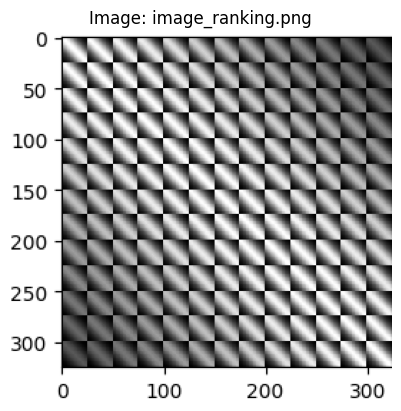

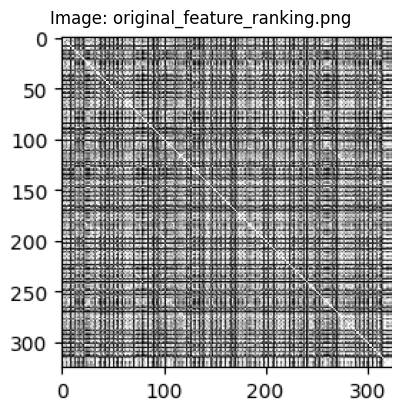

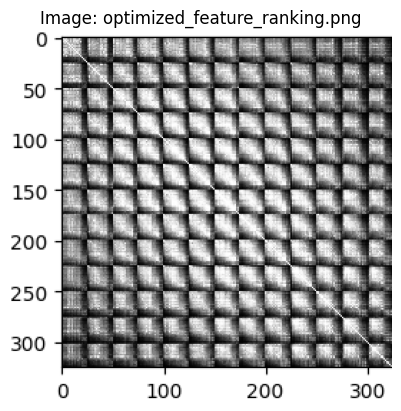

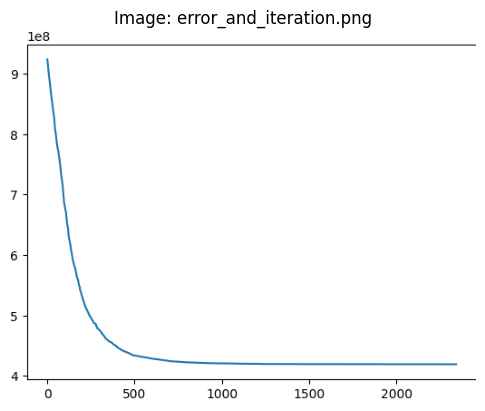

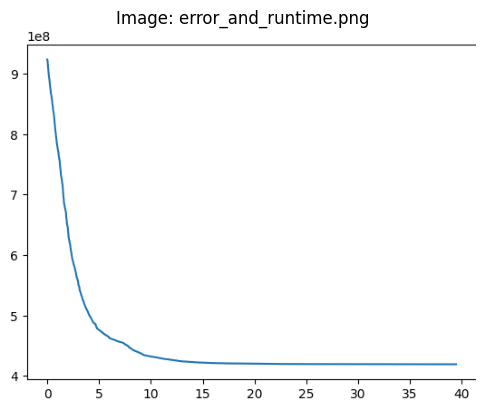

In [ ]:
image_dir = '../Results/Table_To_Image_Conversion/Test_3'
images = [f for f in os.listdir(image_dir) if f.endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

for img_file in images:
    img_path = os.path.join(image_dir, img_file)
    img = Image.open(img_path)
    plt.figure()
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Image: {img_file}")
    plt.show()

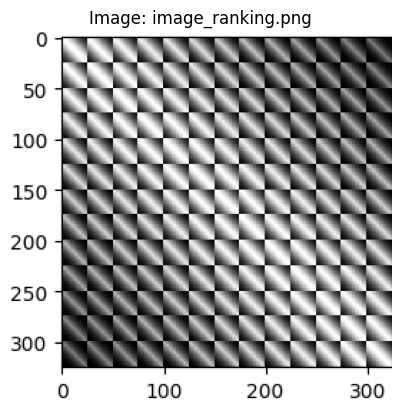

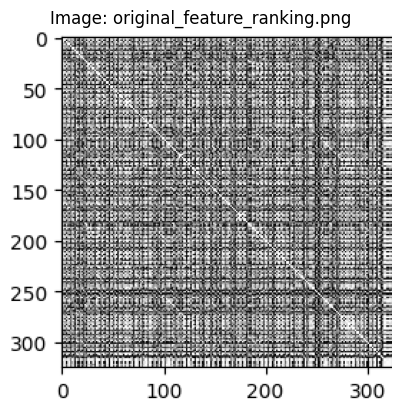

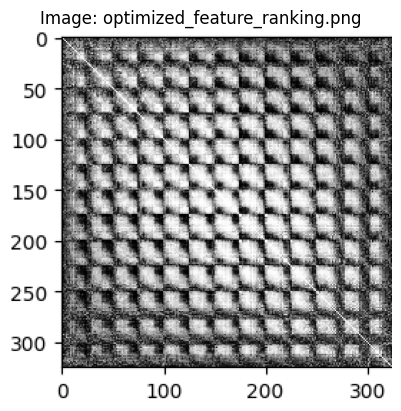

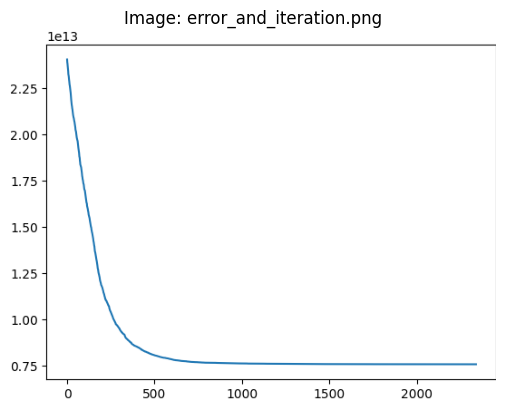

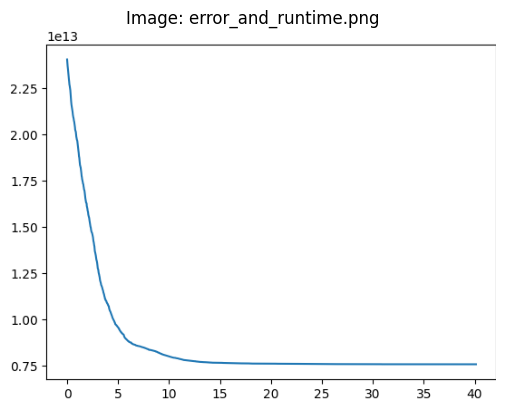

In [ ]:
image_dir = '../Results/Table_To_Image_Conversion/Test_4'
images = [f for f in os.listdir(image_dir) if f.endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

for img_file in images:
    img_path = os.path.join(image_dir, img_file)
    img = Image.open(img_path)
    plt.figure()
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Image: {img_file}")
    plt.show()

Nota: no es necesario guardar los resultados. Los sets de imágenes generados en este cuaderno son accesados por los siguientes notebooks a partir de Github.

In [ ]:
import os
import shutil
from google.colab import files

# Path to your image directory
image_dir = '../Results/Table_To_Image_Conversion/Test_3'

# Name of the zip file
zip_path = 'images_test_3.zip'

# Create a zip of the directory
shutil.make_archive('images_test_3', 'zip', image_dir)

# Download the zip file
files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>